<div dir="rtl" style="text-align: center; line-height: 2; font-family: Tahoma;">
    <b style="font-size: 20px;">سوال ۸ آمار توصیفی</b>
</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
در این سوال می‌خواهیم ماتریس همبستگی را برای ویژگی‌های ‫مبلغ‬ ‫قیمت‪،‬‬ ‫متراژ‬ ‫زمین‪،‬‬ ‫زیربنا‪،‬‬ ‫ظرفیت‬ ‫نفرات‪،‬‬ ‫تعداد‬ ‫اتاق‌ها‬ ‫و ‬طول‬ ‫و‬ ‫عرض‬ جغرافیایی رسم کنیم. این ماتریس را به صورت heatmap نمایش خواهیم داد.
</div>

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Divar_Iran.csv", low_memory=False)

In [3]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
2,7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
3,8,residential-sell,apartment-sell,mahdasht-city,NaN,2024-06-01 00:00:00,مشاور املاک,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,500.0
4,10,residential-sell,apartment-sell,pardis-city,NaN,2024-11-01 00:00:00,NaN,سردرب عالی \nویو عالی بدون مشرف \nنصبیات نصب ش...,فاز ۱۱ زون ۲ ساخت شرکت کوزو ترکیه,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.778664,51.757549,NaN


In [4]:
df = df.drop('Unnamed: 0', axis=1)

In [5]:
df.columns.tolist()

['cat2_slug',
 'cat3_slug',
 'city_slug',
 'neighborhood_slug',
 'created_at_month',
 'user_type',
 'description',
 'title',
 'rent_mode',
 'rent_value',
 'rent_to_single',
 'rent_type',
 'price_mode',
 'price_value',
 'credit_mode',
 'credit_value',
 'rent_credit_transform',
 'transformable_price',
 'transformable_credit',
 'transformed_credit',
 'transformable_rent',
 'transformed_rent',
 'land_size',
 'building_size',
 'deed_type',
 'has_business_deed',
 'floor',
 'rooms_count',
 'total_floors_count',
 'unit_per_floor',
 'has_balcony',
 'has_elevator',
 'has_warehouse',
 'has_parking',
 'construction_year',
 'is_rebuilt',
 'has_water',
 'has_warm_water_provider',
 'has_electricity',
 'has_gas',
 'has_heating_system',
 'has_cooling_system',
 'has_restroom',
 'has_security_guard',
 'has_barbecue',
 'building_direction',
 'has_pool',
 'has_jacuzzi',
 'has_sauna',
 'floor_material',
 'property_type',
 'regular_person_capacity',
 'extra_person_capacity',
 'cost_per_extra_person',
 'rent_

In [6]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.497390e+05,5.663770e+05,3.505110e+05,3.505010e+05,7.220800e+04,3.496650e+05,7.220800e+04,1.858190e+05,9.764240e+05,29565.000000,1.014600e+04,1.788900e+04,1.036300e+04,1.342500e+04,651547.000000,651547.000000,338284.000000
mean,4.120860e+10,1.736190e+10,4.890095e+10,4.890234e+10,8.578978e+09,4.121732e+10,1.621278e+07,4.169838e+03,4.441727e+03,6.566176,1.221113e+10,1.402914e+11,2.378276e+10,3.186174e+10,35.020285,51.614313,465.140828
std,3.816141e+12,5.885228e+11,4.351102e+12,4.351164e+12,2.067448e+12,3.816544e+12,5.224585e+07,1.220538e+05,1.365971e+05,7.720746,1.108636e+12,7.077468e+12,1.549470e+12,2.446341e+12,2.318377,3.153521,125.911512
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,25.135723,44.147400,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,5.925000e+05,5.500000e+05,34.608070,50.673065,500.000000
50%,5.000000e+06,2.830000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.724125,51.343872,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.308702,51.788145,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,39.678127,62.843330,500.000000


In [7]:
df["rooms_count"].value_counts()

rooms_count
دو              402472
یک              191365
سه              137979
بدون اتاق        75476
چهار             21287
پنج یا بیشتر     13822
Name: count, dtype: int64

In [8]:
# Convert rooms_count values to number 
rooms_count_map = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df["rooms_count"] = df["rooms_count"].map(rooms_count_map)

In [9]:
features = [
    "price_value",
    "land_size",
    "building_size",
    "rooms_count",
    "regular_person_capacity",
    "location_latitude",
    "location_longitude"
]

df_selected = df[features].copy()

In [10]:
df_selected.head()

,price_value,land_size,building_size,rooms_count,regular_person_capacity,location_latitude,location_longitude
0,NaN,NaN,500.0,3.0,4.0,35.811684,50.936600
1,NaN,NaN,132.0,3.0,NaN,35.703865,51.373459
2,8.700000e+09,NaN,100.0,2.0,NaN,35.729832,51.505466
3,6.500000e+08,NaN,78.0,2.0,NaN,35.712364,50.794781
4,2.600000e+09,NaN,87.0,2.0,NaN,35.778664,51.757549


<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
ضریب همبستگی Pearson میزان رابطه خطی بین دو متغیر عددی را اندازه‌گیری می‌کند و مقداری بین -1 تا 1 دارد.
</div>
<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
رابطه آن به صورت زیر می‌باشد:
</div>

$$
r=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}
$$

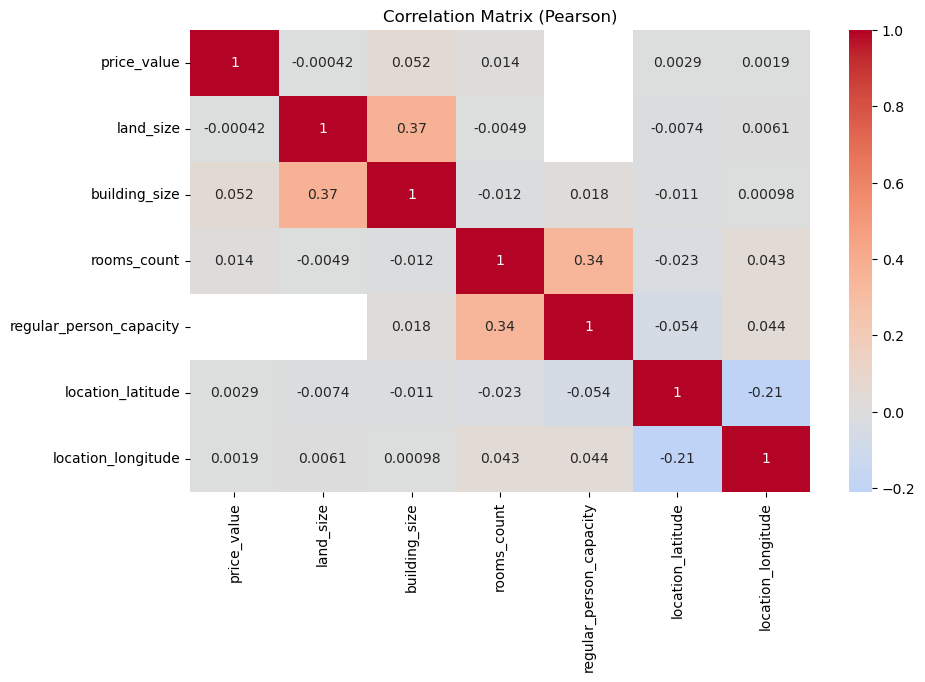

In [11]:
# Plot Pearson correlation matrix
corr = df_selected.corr(method="pearson")

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Pearson)")
plt.show()

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
ضریب همبستگی Spearman میزان رابطه یکنواخت بین دو متغیر را با استفاده از رتبه داده‌ها اندازه‌گیری می‌کند و مقداری بین -1 تا 1 دارد. 
</div>
</div>
<div dir="rtl" style="text-align: right; line-height: 2; font-family: Tahoma; font-size: 16px;">
رابطه آن به صورت زیر می‌باشد:
</div>

$$
\rho=
1-\frac{6\sum_{i=1}^{n}d_i^2}{n(n^2-1)}
$$

$$
d_i=R(x_i)-R(y_i)
$$

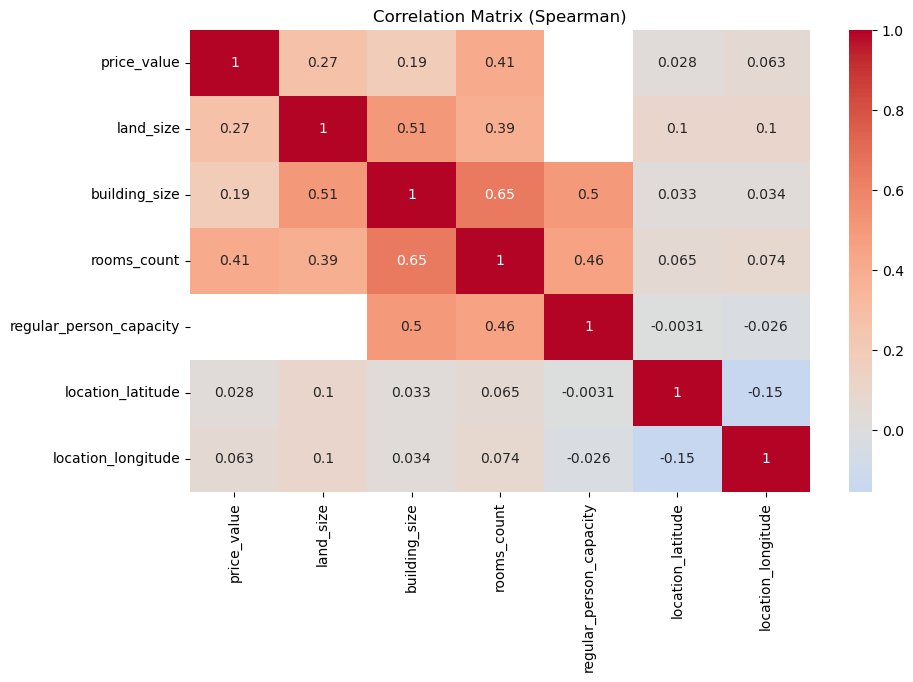

In [12]:
# Plot Spearman correlation matrix
corr = df_selected.corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Spearman)")
plt.show()